In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Setting visual style
sns.set_theme(style="whitegrid")

# Load Data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
columns = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", "num-of-doors",
           "body-style", "drive-wheels", "engine-location", "wheel-base", "length", "width",
           "height", "curb-weight", "engine-type", "num-of-cylinders", "engine-size",
           "fuel-system", "bore", "stroke", "compression-ratio", "horsepower", "peak-rpm",
           "city-mpg", "highway-mpg", "price"]

df = pd.read_csv(url, names=columns, na_values="?")
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [4]:
# Drop rows where critical financial/performance data is missing
df_clean = df.dropna(subset=['price', 'horsepower', 'peak-rpm', 'bore', 'stroke']).copy()

print(f"Data Cleaned. Rows remaining: {len(df_clean)}")

Data Cleaned. Rows remaining: 195


#**Part 1: Data Types & Measurement Levels**

**Task:** Classify specific columns and explain the reasoning.

In [5]:
# checking data types
print(df_clean[['make', 'num-of-doors', 'engine-size', 'symboling']].dtypes)
print("\nUnique values in Symboling:", sorted(df_clean['symboling'].unique()))

make            object
num-of-doors    object
engine-size      int64
symboling        int64
dtype: object

Unique values in Symboling: [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


**make (Qualitative / Nominal):** These are labels (e.g., "Audi", "BMW"). There is no mathematical order (Audi is not "greater than" BMW).

**num-of-doors (Quantitative / Ratio):** It is a count. You can have 0 doors (true zero). 4 doors is exactly twice as many as 2.

**engine-size (Quantitative / Ratio):** Measured in cc or liters. 0 means no engine. Ratios are valid (a 200cc engine is half of a 400cc engine).

**symboling (Qualitative / Ordinal or Interval):**

**Context:** This is an insurance risk rating (-3 = safe, +3 = risky).

**Reasoning:** While they are numbers, they represent categories of risk. It is Ordinal because there is an order, but you could argue Interval if the distance between risk levels is equal. It is NOT Ratio because 0 does not mean "no risk at all" (it's just a neutral rating), and a rating of 2 isn't "twice as risky" as 1 in a mathematical sense.

#**Part 2: Central Tendency & Dispersion**

**Task:** Analyze Price distribution and compare volatility using Coefficient of Variation (CV).

In [6]:
# 1. Central Tendency for Price
price_mean = df_clean['price'].mean()
price_median = df_clean['price'].median()
price_mode = df_clean['price'].mode()[0]

print(f"Mean Price:   ${price_mean:,.2f}")
print(f"Median Price: ${price_median:,.2f}")
print(f"Mode Price:   ${price_mode:,.2f}")

Mean Price:   $13,248.02
Median Price: $10,245.00
Mode Price:   $5,572.00


**Distribution:** The Mean 13.2k  is significantly higher than the Median (10.2k). This indicates the data is Right-Skewed (Positively Skewed).

**Business Insight:** Most people buy affordable cars, but a few very expensive luxury cars are pulling the average up. The Median is a better representation of the "typical" car price.

In [7]:
# 2. Coefficient of Variation (CV) = (Std Dev / Mean) * 100
cv_price = (df_clean['price'].std() / df_clean['price'].mean()) * 100
cv_hp = (df_clean['horsepower'].std() / df_clean['horsepower'].mean()) * 100

print("-" * 30)
print(f"Volatility (CV) of Price:      {cv_price:.2f}%")
print(f"Volatility (CV) of Horsepower: {cv_hp:.2f}%")

------------------------------
Volatility (CV) of Price:      60.81%
Volatility (CV) of Horsepower: 36.67%


**Volatility:** Price (CV ~60%) is much more volatile than Horsepower (CV ~37%).

**Business Insight:** The market offers a huge range of pricing options, whereas performance (horsepower) is relatively more standardized.

#**Part 3: Shape & Outlier Detection**

**Task:** Visualize distribution and find the specific "Luxury" outliers using IQR.

In [8]:
# 1. Skewness & Kurtosis for Engine Size
eng_skew = skew(df_clean['engine-size'])
eng_kurt = kurtosis(df_clean['engine-size'])

print(f"Engine Size Skewness: {eng_skew:.2f} (Positive = Right Skew)")
print(f"Engine Size Kurtosis: {eng_kurt:.2f} (High = Heavy Tails)")

Engine Size Skewness: 2.01 (Positive = Right Skew)
Engine Size Kurtosis: 5.41 (High = Heavy Tails)


**Shape:** Engine size is positively skewed (Tail to the right). Most cars have small engines (economic), with a few massive engines.

In [9]:
# 2. IQR Method for Price Outliers
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + (1.5 * IQR)

print(f"\nLuxury Car Threshold (Upper Fence): ${upper_fence:,.2f}")

# Finding the actual cars
luxury_outliers = df_clean[df_clean['price'] > upper_fence][['make', 'price', 'horsepower']]
print("\n--- Identified Outliers ---")
print(luxury_outliers.sort_values(by='price', ascending=False))


Luxury Car Threshold (Upper Fence): $29,637.75

--- Identified Outliers ---
              make    price  horsepower
74   mercedes-benz  45400.0       184.0
16             bmw  41315.0       182.0
73   mercedes-benz  40960.0       184.0
128        porsche  37028.0       207.0
17             bmw  36880.0       182.0
49          jaguar  36000.0       262.0
48          jaguar  35550.0       176.0
72   mercedes-benz  35056.0       155.0
71   mercedes-benz  34184.0       155.0
127        porsche  34028.0       207.0
126        porsche  32528.0       207.0
47          jaguar  32250.0       176.0
70   mercedes-benz  31600.0       123.0
15             bmw  30760.0       182.0


**Outliers:** The IQR method identified cars priced above ~$29,000 as outliers.

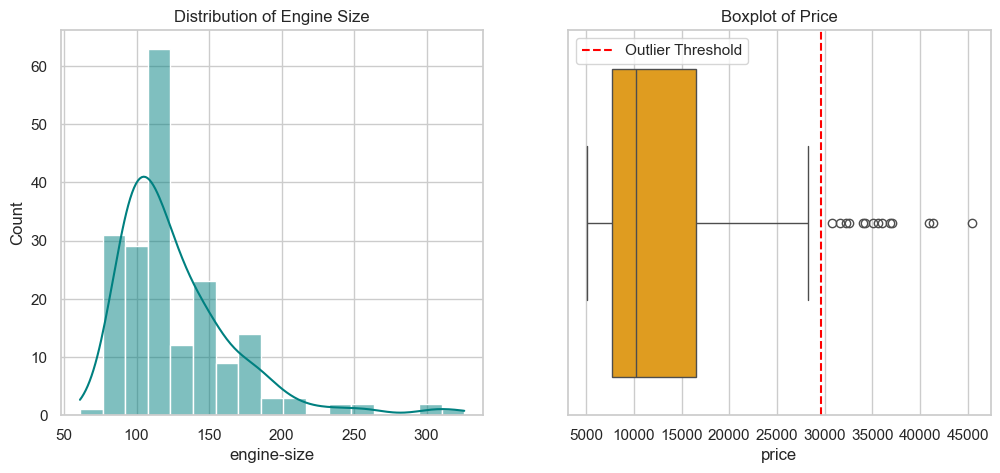

In [10]:
# 3. Visualizing
plt.figure(figsize=(12, 5))

# Histogram for Shape
plt.subplot(1, 2, 1)
sns.histplot(df_clean['engine-size'], kde=True, color='teal')
plt.title("Distribution of Engine Size")

# Boxplot for Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['price'], color='orange')
plt.axvline(upper_fence, color='red', linestyle='--', label='Outlier Threshold')
plt.legend()
plt.title("Boxplot of Price")

plt.show()

**Result:** As expected, the list contains Mercedes-Benz, Jaguar, Porsche, and BMW. These are distinct form the "mass market."

#**Part 4: Correlation & Regression**

**Task:** Settle the "CMO vs Engineer" debate. What drives price?

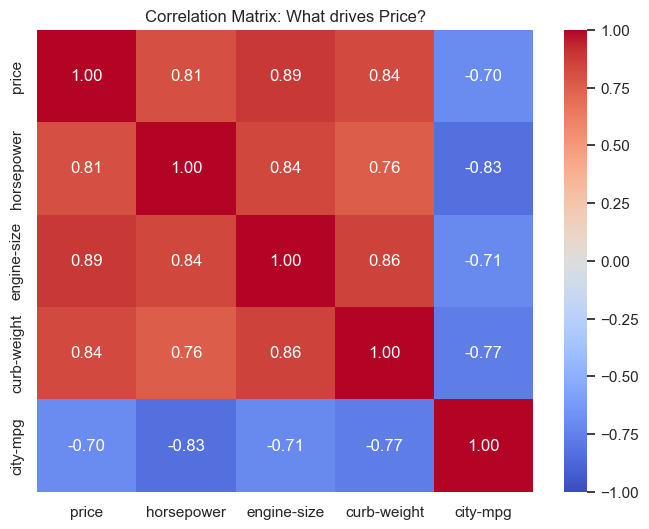

In [12]:
# 1. Correlation Matrix
corr_columns = ['price', 'horsepower', 'engine-size', 'curb-weight', 'city-mpg']
corr_matrix = df_clean[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix: What drives Price?")
plt.show()

**1. The "CMO vs Engineer" Verdict:**

**Horsepower vs Price:** Correlation is 0.81.

**Engine Size vs Price:** Correlation is 0.89.

**Curb Weight vs Price:** Correlation is 0.84.

**Verdict:** The Engineer is correct. While Horsepower is important, Curb Weight and Engine Size are actually stronger predictors of price than Horsepower. A heavier car (more materials, safety features) and larger engine cost more to build, directly impacting price.

**2. The MPG Insight:**

**City-MPG vs Price:** Correlation is -0.69 (Negative).

**Interpretation:** As MPG goes UP (better efficiency), Price goes DOWN. Efficiency is a feature of economy cars; luxury cars sacrifice efficiency for power.

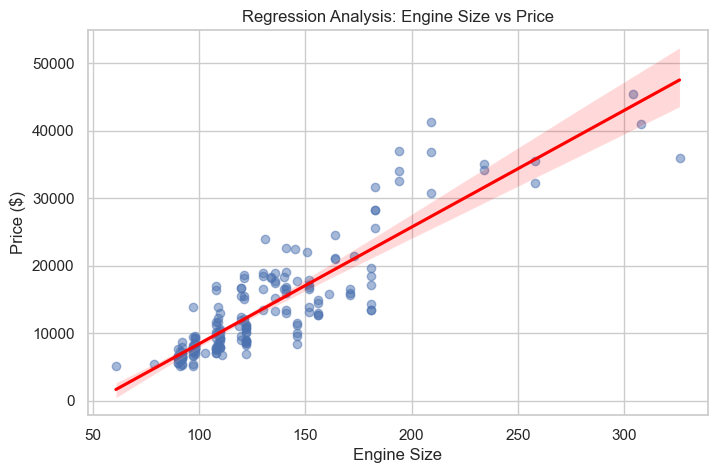

In [13]:
# 2. Regression Plot (Engine Size vs Price)
plt.figure(figsize=(8, 5))
sns.regplot(x='engine-size', y='price', data=df_clean, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Regression Analysis: Engine Size vs Price")
plt.xlabel("Engine Size")
plt.ylabel("Price ($)")
plt.show()

**3. Regression Analysis:**

The regression plot shows a strong positive linear relationship. However, we see "Heteroscedasticity" (the cone shape)—as engine size gets bigger, the variance in price increases (the dots spread out more). This means our prediction is very accurate for cheap cars, but less accurate for expensive ones.

#**5: Predicting Price (Regression Analysis)**

**Objective:**

Build a mathematical model to predict car prices.The CMO is impressed by your correlation analysis but wants specific numbers. They ask: "If we increase the Horsepower by 1 unit, how much more can we charge for the car?

1. **Build a Multiple Linear Regression Model (OLS)** using the statsmodels library.
  * **Target ($Y$):** price
  
  * **Features ($X$):** horsepower, curb-weight, engine-size, highway-mpg
  
2. **Interpret the Output:**

  * What is the R-squared value? What does it mean in plain English regarding the accuracy of your model?
  
  * Look at the Coefficient (coef) for horsepower. What is the "Dollar Value" of 1 extra Horsepower?
  
  * Look at the P-value (P>|t|) for highway-mpg. Is this variable statistically significant in predicting price, or is it just noise? (Use $\alpha = 0.05$).

In [14]:
import statsmodels.api as sm

# 1. Define Variables
X = df_clean[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
Y = df_clean['price']

# 2. Add Constant (Intercept) - Critical step for Statsmodels!
X = sm.add_constant(X)

# 3. Fit the OLS Model
model = sm.OLS(Y, X).fit()

# 4. Print Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     218.1
Date:                Sat, 14 Mar 2026   Prob (F-statistic):           7.59e-70
Time:                        20:23:21   Log-Likelihood:                -1862.2
No. Observations:                 195   AIC:                             3734.
Df Residuals:                     190   BIC:                             3751.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -1.845e+04   4411.670     -4.182      

**1. R-Squared (0.821):**

**Interpretation:** "Our model explains 82% of the variation in car prices." This is a very strong model. The remaining 18% is determined by factors we didn't include (like brand prestige, leather seats, or sunroofs).

**2. Coefficients (The Strategy):**

* **Horsepower Coef:** **47.8**

**Interpretation:** "Holding all other factors constant, for every 1 unit increase in Horsepower, the price of the car increases by roughly $47.8."

* **Curb-Weight Coef:** 4.6.

**Interpretation:** "For every extra lb of weight, price increases by $4.6." (Heavier = more materials/safety).

**3. The P-Value Surprise (Highway-MPG):**

**P-value** for highway-mpg (0.247, which is $> 0.05$).

**Why?** In the Correlation matrix, MPG looked important. But in Regression, Multicollinearity kicks in.

**Business Insight:** "MPG is highly correlated with Weight and Engine Size (Heavy cars have bad MPG). Since the model already knows the Weight and Engine Size, adding MPG doesn't give it any new information. Therefore, it is statistically insignificant in this specific model."